In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for charts
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("../data/housing.csv")

# Display the first 5 rows
print("--- FIRST 5 ROWS ---")
df.head()

--- FIRST 5 ROWS ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
print("--- DATA SUMMARY & MISSING VALUES ---")
df.info()

print("\n--- MISSING VALUES COUNT ---")
print(df.isnull().sum())

--- DATA SUMMARY & MISSING VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

--- MISSING VALUES COUNT ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
m

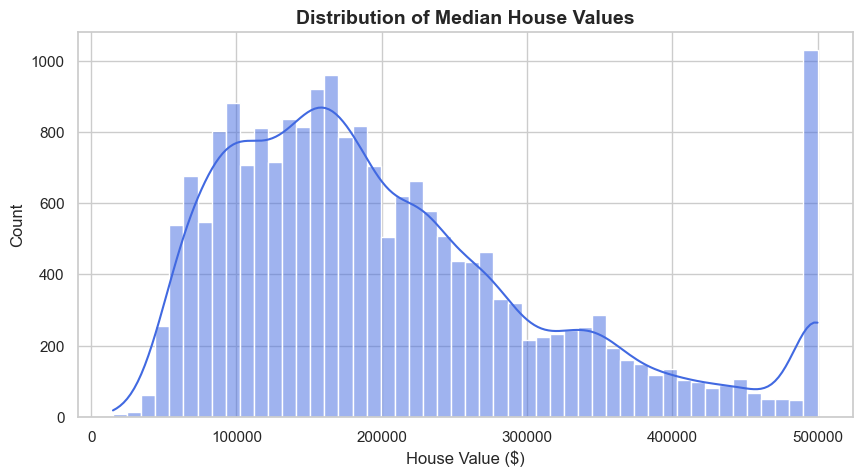

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='royalblue')
plt.title('Distribution of Median House Values', fontsize=14, fontweight='bold')
plt.xlabel('House Value ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

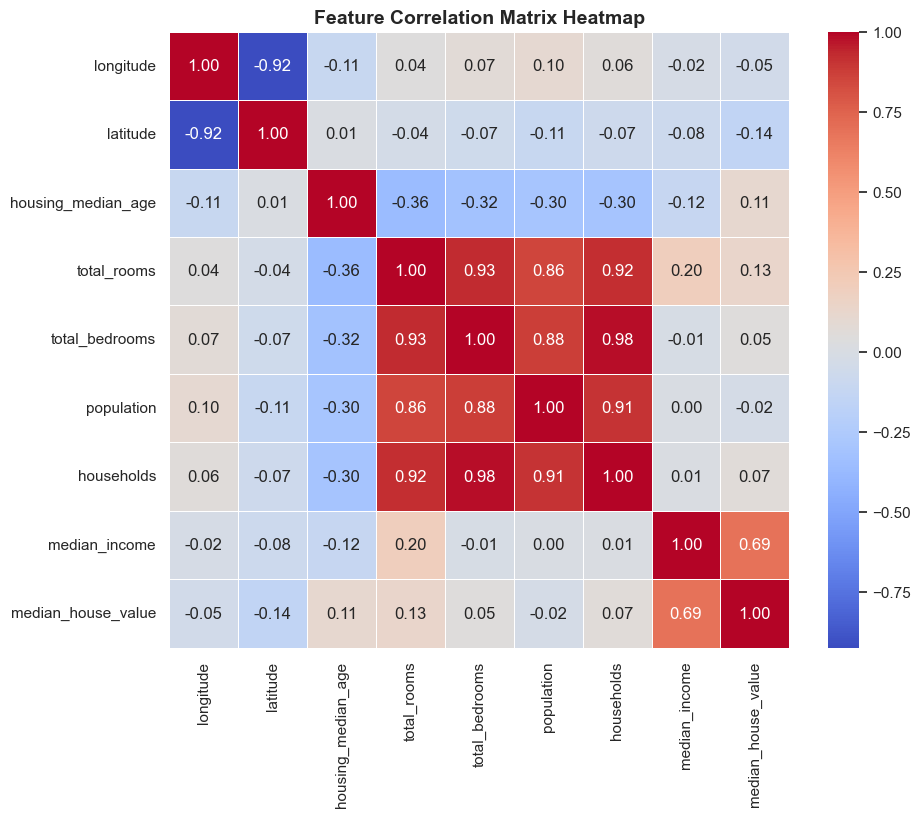

In [9]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()

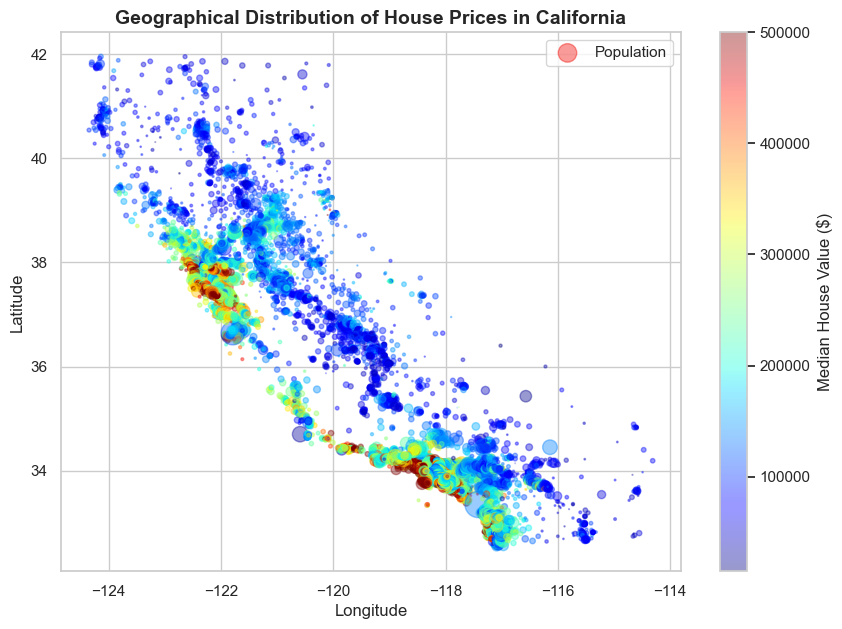

In [10]:
plt.figure(figsize=(10, 7))

# Create the scatter plot (without the colorbar argument inside)
scatter = plt.scatter(df['longitude'], df['latitude'], alpha=0.4,
                      s=df['population']/100, label='Population',
                      c=df['median_house_value'], cmap=plt.get_cmap('jet'))

# Add the colorbar correctly on its own line
plt.colorbar(scatter, label="Median House Value ($)")

# Add labels and title
plt.ylabel("Latitude", fontsize=12)
plt.xlabel("Longitude", fontsize=12)
plt.title("Geographical Distribution of House Prices in California", fontsize=14, fontweight='bold')
plt.legend()
plt.show()